# Chapter 13 - Support Vector Machine

In this chapter, we study Support Vector Machine (SVM), one of the important classical Machine Learning algorithms.

The main idea is simple: when many decision boundaries can separate two classes, SVM chooses the boundary that keeps the largest possible gap from the nearest training points. This gap is called the margin, and the nearest points are called support vectors.

We will do three practical demonstrations ahead:

- a linear SVM classifier
- a non-linear SVM classifier using the RBF kernel
- a Support Vector Regression (SVR) model

## Step 1 - Import Required Libraries

In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_moons
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, SVR

np.random.seed(42)

## Step 2 - Linear SVM Classifier

We first create a simple two-feature classification dataset. The classes are mostly linearly separable, so a linear SVM is a good starting point.

A linear SVM learns a straight decision boundary in 2D. 

The regularization parameter C controls the trade-off between a wider margin and fewer training errors.

In [2]:
# Create a synthetic dataset with two informative features and two classes.
X_linear, y_linear = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=2.0,
    random_state=42,
)

print("Feature matrix shape:", X_linear.shape)
print("Target vector shape:", y_linear.shape)

print("\nClass counts:", np.bincount(y_linear))

print("\nFirst five rows of X:")
print(X_linear[:5])

Feature matrix shape: (200, 2)
Target vector shape: (200,)

Class counts: [100 100]

First five rows of X:
[[0.12707102 1.013042  ]
 [2.31293463 3.77053357]
 [3.34042818 3.42099601]
 [3.29454774 0.59561981]
 [1.94410516 1.4772409 ]]


The preview confirms that the dataset has 200 rows, 2 input features, and a balanced binary target. 

Now we split the data and train the linear SVM.

In [3]:
# Keep 20 percent of the data aside for testing.
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear,
    y_linear,
    test_size=0.2,
    random_state=42,
)

# kernel="linear" tells SVC to learn a straight boundary.
linear_model = SVC(kernel="linear", C=1.0)
linear_model.fit(X_train_linear, y_train_linear)

# Predict on unseen test data and evaluate the result.
y_pred_linear = linear_model.predict(X_test_linear)

print("Linear SVM accuracy:", accuracy_score(y_test_linear, y_pred_linear))

print("\nNumber of support vectors per class:", linear_model.n_support_)

print("\nClassification Report :\n") 
print(classification_report(y_test_linear, y_pred_linear))

Linear SVM accuracy: 0.975

Number of support vectors per class: [8 8]

Classification Report :

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        23
           1       0.94      1.00      0.97        17

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40



The accuracy is high because the generated data is close to linearly separable. 

The support-vector count shows how many training points are closest enough to the boundary to shape the final model.

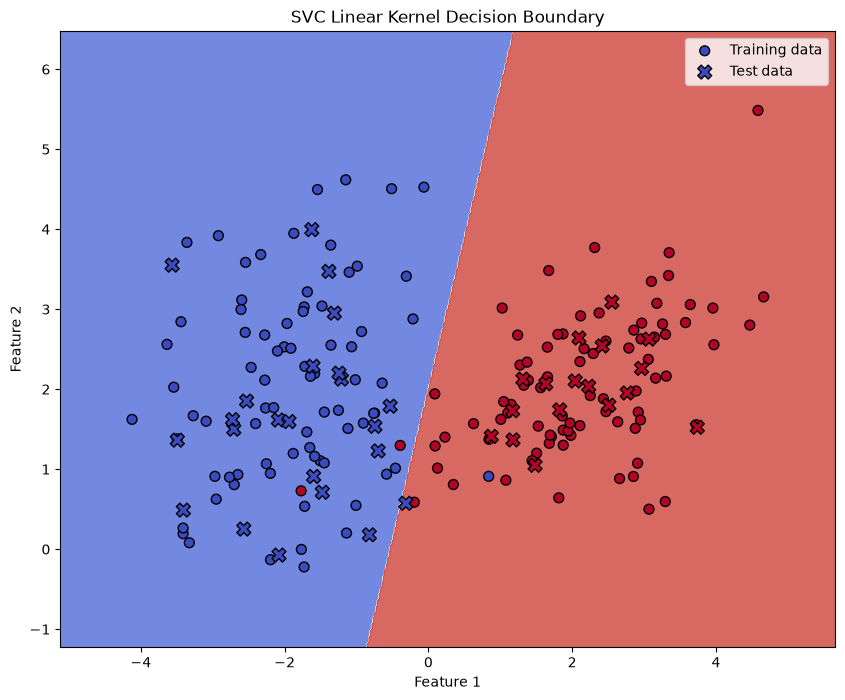

In [4]:
def plot_svm_decision_boundary(model, X, X_train, y_train, X_test, y_test, title):
    """Plot the SVM decision region for a two-feature dataset."""
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02),
    )

    # Predict one class for every point in the grid, then color the grid.
    grid_predictions = model.predict(np.c_[xx.ravel(), yy.ravel()])
    grid_predictions = grid_predictions.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, grid_predictions, cmap=plt.cm.coolwarm, alpha=0.8)

    plt.scatter(
        X_train[:, 0],
        X_train[:, 1],
        c=y_train,
        cmap=plt.cm.coolwarm,
        s=50,
        edgecolors="k",
        label="Training data",
    )
    plt.scatter(
        X_test[:, 0],
        X_test[:, 1],
        c=y_test,
        cmap=plt.cm.coolwarm,
        marker="X",
        s=100,
        edgecolors="k",
        label="Test data",
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.show()


plot_svm_decision_boundary(
    linear_model,
    X_linear,
    X_train_linear,
    y_train_linear,
    X_test_linear,
    y_test_linear,
    "SVC Linear Kernel Decision Boundary",
)

The plot shows the main behavior of the linear kernel: it separates the classes with one straight boundary. 

This is efficient and interpretable when the data structure is close to linear.

## Step 3 - Non-Linear SVM with RBF Kernel

Many datasets cannot be separated with one straight line. Let's use the two-moons dataset to demonstrate this problem.

The RBF kernel lets SVM create a curved decision boundary without manually adding transformed features. The parameter gamma="scale" lets Scikit-Learn choose a practical default based on the data.

Feature matrix shape: (300, 2)
Target vector shape: (300,)

Class counts: [150 150]


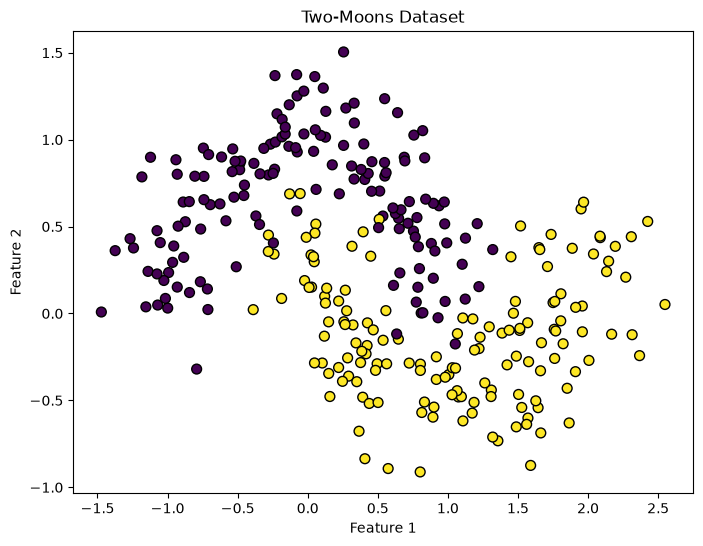

In [5]:
# make_moons creates two curved classes that overlap in a non-linear shape.
X_rbf, y_rbf = make_moons(n_samples=300, noise=0.2, random_state=42)

print("Feature matrix shape:", X_rbf.shape)
print("Target vector shape:", y_rbf.shape)
print("\nClass counts:", np.bincount(y_rbf))

plt.figure(figsize=(8, 6))
plt.scatter(X_rbf[:, 0], X_rbf[:, 1], c=y_rbf, cmap="viridis", s=50, edgecolors="k")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two-Moons Dataset")
plt.show()

The scatter plot shows why a non-linear model is useful here. The two classes bend around each other, so a straight boundary would struggle.

In [6]:
X_train_rbf, X_test_rbf, y_train_rbf, y_test_rbf = train_test_split(
    X_rbf,
    y_rbf,
    test_size=0.2,
    random_state=42,
)

# The RBF kernel measures similarity by distance, so nearby points influence each other more.
rbf_model = SVC(kernel="rbf", C=1.0, gamma="scale")
rbf_model.fit(X_train_rbf, y_train_rbf)

y_pred_rbf = rbf_model.predict(X_test_rbf)

print("RBF SVM accuracy:", accuracy_score(y_test_rbf, y_pred_rbf))

print("\nNumber of support vectors per class:", rbf_model.n_support_)

print("\nClassification Report :\n") 
print(classification_report(y_test_rbf, y_pred_rbf))

RBF SVM accuracy: 0.9833333333333333

Number of support vectors per class: [31 31]

Classification Report :

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        26
           1       0.97      1.00      0.99        34

    accuracy                           0.98        60
   macro avg       0.99      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



The RBF SVM performs well because it can bend the boundary around the curved class structure.

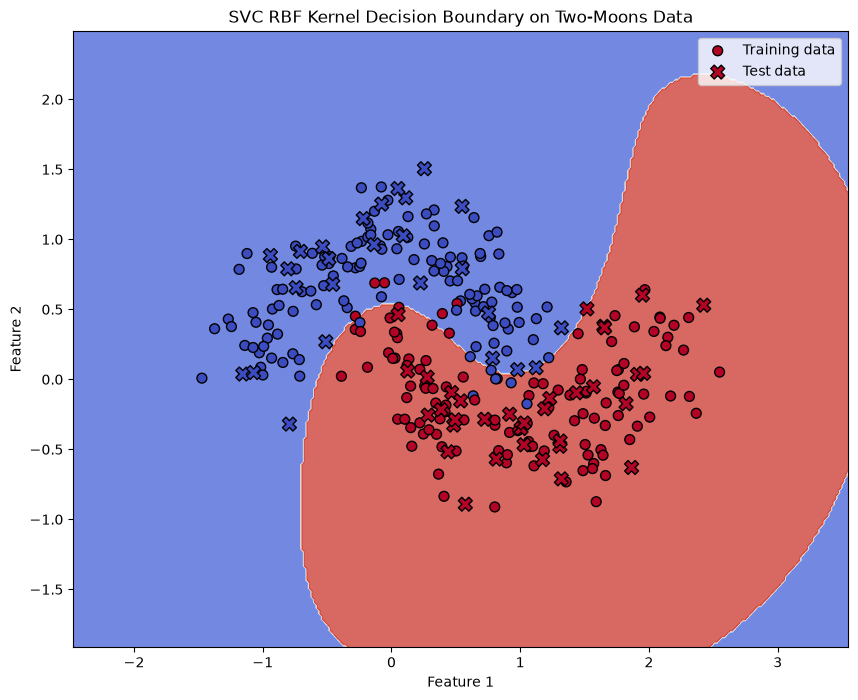

In [7]:
plot_svm_decision_boundary(
    rbf_model,
    X_rbf,
    X_train_rbf,
    y_train_rbf,
    X_test_rbf,
    y_test_rbf,
    "SVC RBF Kernel Decision Boundary on Two-Moons Data",
)

The decision-boundary plot shows the kernel trick in practice. 

The model behaves as if it learned in a transformed space, but we only supplied the original two features.

## Step 4 - Support Vector Regression

SVM ideas also extend to regression. Support Vector Regression (SVR) predicts continuous values instead of class labels.

SVR uses an epsilon-insensitive tube around the fitted function. 

Errors inside the tube are ignored, while points outside the tube receive a penalty. The main parameters are:

- epsilon: the tube width
- C: the penalty for points outside the tube
- kernel: the function used to model the relationship

Regression feature shape: (80, 1)
First five target values: [-0.22237602  0.19002495  0.30627715  0.57278841  0.36879459]


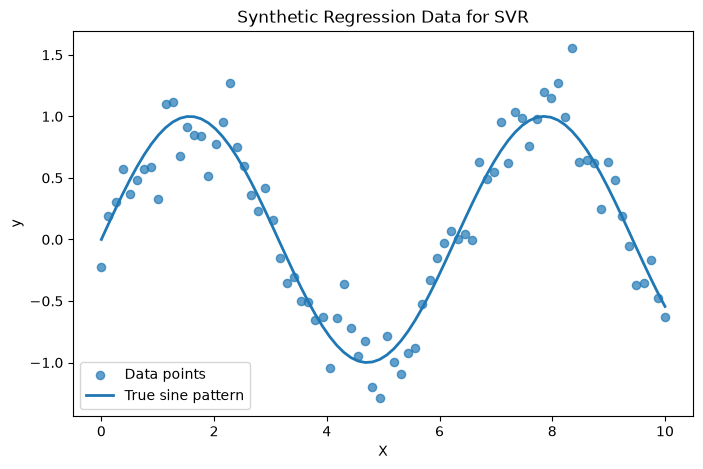

In [8]:
# Create the synthetic regression setup used to explain C and epsilon behavior
X_svr_curve = np.linspace(0, 10, 80).reshape(-1, 1)
y_true_curve = np.sin(X_svr_curve).ravel()
noise = np.random.normal(0, 0.2, size=len(X_svr_curve))
y_svr_curve = y_true_curve + noise

X_plot_curve = np.linspace(0, 10, 500).reshape(-1, 1)

print("Regression feature shape:", X_svr_curve.shape)
print("First five target values:", y_svr_curve[:5])

plt.figure(figsize=(8, 5))
plt.scatter(X_svr_curve, y_svr_curve, s=35, alpha=0.7, label="Data points")
plt.plot(X_svr_curve, y_true_curve, linewidth=2, label="True sine pattern")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Regression Data for SVR")
plt.legend()
plt.show()

The data follows a noisy sine pattern. SVR should learn the broad curve without trying to pass through every noisy point.

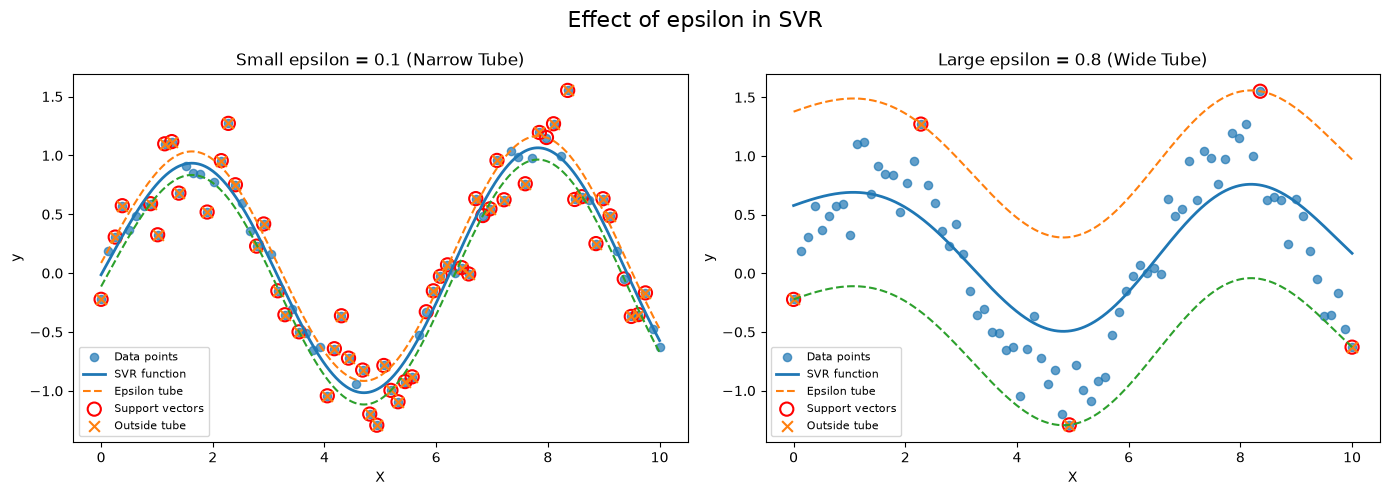

In [9]:
def plot_svr(ax, C, epsilon, title):
    """Fit an RBF SVR model and display its epsilon tube."""
    model = SVR(kernel="rbf", C=C, epsilon=epsilon, gamma="scale")
    model.fit(X_svr_curve, y_svr_curve)

    y_plot_pred = model.predict(X_plot_curve)
    y_train_pred = model.predict(X_svr_curve)

    # Points outside the epsilon tube are the ones that receive loss.
    outside_tube = np.abs(y_svr_curve - y_train_pred) > epsilon

    ax.scatter(X_svr_curve, y_svr_curve, s=35, alpha=0.7, label="Data points")
    ax.plot(X_plot_curve, y_plot_pred, linewidth=2, label="SVR function")
    ax.plot(X_plot_curve, y_plot_pred + epsilon, linestyle="--", linewidth=1.5, label="Epsilon tube")
    ax.plot(X_plot_curve, y_plot_pred - epsilon, linestyle="--", linewidth=1.5)

    ax.scatter(
        model.support_vectors_,
        y_svr_curve[model.support_],
        s=90,
        facecolors="none",
        edgecolors="red",
        linewidths=1.5,
        label="Support vectors",
    )

    ax.scatter(
        X_svr_curve[outside_tube],
        y_svr_curve[outside_tube],
        s=60,
        marker="x",
        linewidths=1.5,
        label="Outside tube",
    )

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_svr(axes[0], C=10, epsilon=0.1, title="Small epsilon = 0.1 (Narrow Tube)")
plot_svr(axes[1], C=10, epsilon=0.8, title="Large epsilon = 0.8 (Wide Tube)")
fig.suptitle("Effect of epsilon in SVR", fontsize=16)
plt.tight_layout()
plt.show()

A smaller epsilon creates a narrow tube, so more points become support vectors. 

A larger epsilon ignores more small errors and produces a smoother fit.

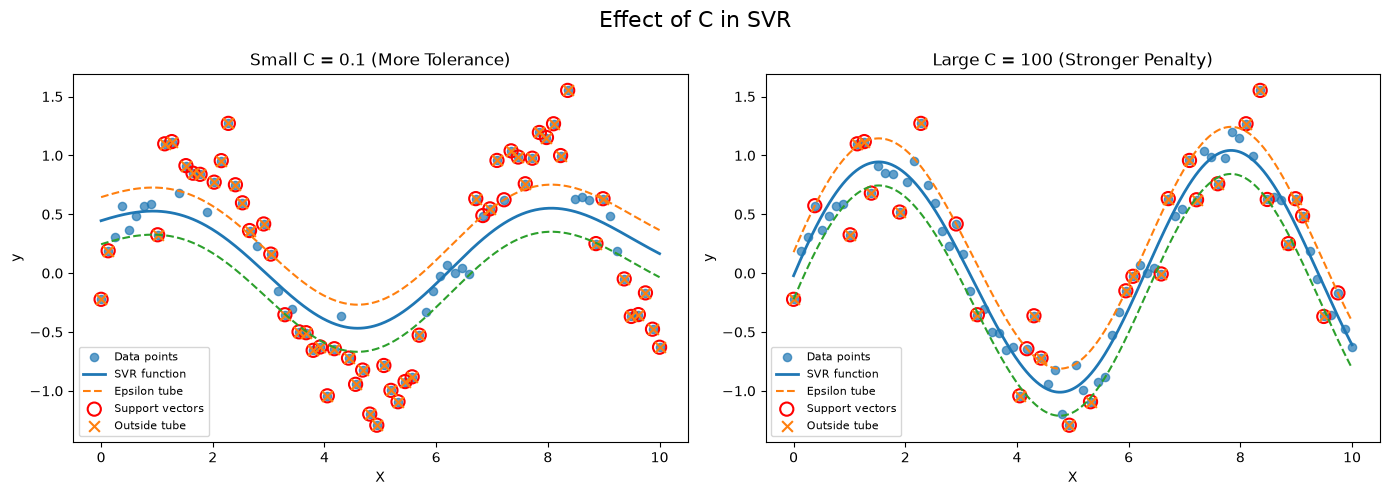

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_svr(axes[0], C=0.1, epsilon=0.2, title="Small C = 0.1 (More Tolerance)")
plot_svr(axes[1], C=100, epsilon=0.2, title="Large C = 100 (Stronger Penalty)")
fig.suptitle("Effect of C in SVR", fontsize=16)
plt.tight_layout()
plt.show()

A smaller C is more tolerant of violations outside the tube. 

A larger C penalizes those violations strongly, so the fitted curve tries harder to stay close to the training data.

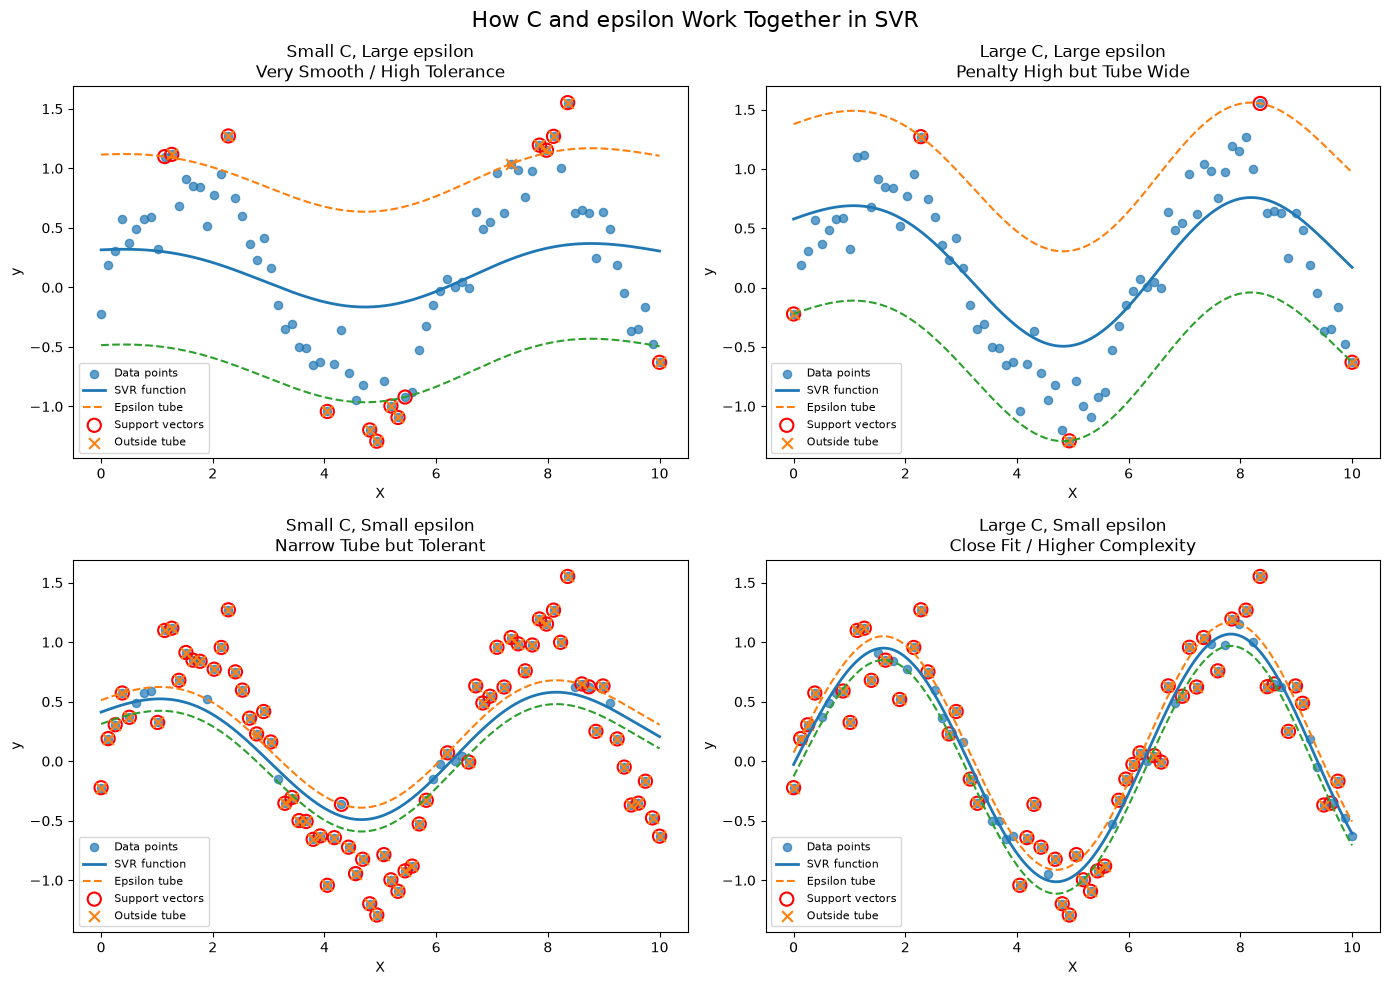

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

settings = [
    (0.1, 0.8, "Small C, Large epsilon\nVery Smooth / High Tolerance"),
    (100, 0.8, "Large C, Large epsilon\nPenalty High but Tube Wide"),
    (0.1, 0.1, "Small C, Small epsilon\nNarrow Tube but Tolerant"),
    (100, 0.1, "Large C, Small epsilon\nClose Fit / Higher Complexity"),
]

for ax, (C, epsilon, title) in zip(axes.ravel(), settings):
    plot_svr(ax, C=C, epsilon=epsilon, title=title)

fig.suptitle("How C and epsilon Work Together in SVR", fontsize=16)
plt.tight_layout()
plt.show()

This comparison shows the two parameters working together. 

The tube width decides which errors matter, and C decides how strongly the model reacts to those errors.

## Step 5 - Small SVR Implementation

Now lets understand SVR with a compact example: create a small dataset, split it, train an RBF SVR model, make predictions, and calculate mean squared error.

In [12]:
# A small one-feature regression dataset from the chapter example.
X_small = np.array([[1], [2], [3], [4], [5], [6]])
y_small = np.array([1.2, 2.1, 2.9, 4.2, 5.1, 6.0])

print("Small SVR dataset:")
print(pd.DataFrame({"X": X_small.ravel(), "y": y_small}))

X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=15,
)

small_svr_model = SVR(kernel="rbf", C=1.0, epsilon=0.1)
small_svr_model.fit(X_train_small, y_train_small)

y_pred_small = small_svr_model.predict(X_test_small)

print("\nTest X values:", X_test_small.ravel())
print("\nActual y values:", y_test_small)
print("Predicted y values:", y_pred_small)
print("\nMSE:", mean_squared_error(y_test_small, y_pred_small))

Small SVR dataset:
   X    y
0  1  1.2
1  2  2.1
2  3  2.9
3  4  4.2
4  5  5.1
5  6  6.0

Test X values: [4 3]

Actual y values: [4.2 2.9]
Predicted y values: [4.15773189 3.04226811]

MSE: 0.011013403513754764


## Chapter Recap

In this chapter we explored SVM, one of the most important algorithms in classical machine learning.
 
Its central idea: when many boundaries can separate two classes, choose the one that maximizes the margin—giving classifiers that are more stable and generalize well.

- SVM chooses a maximum-margin decision boundary and depends mainly on the support vectors near that boundary. 

- Soft-margin SVM uses C to balance margin width against training errors. 

- Kernels, especially RBF, allow SVM to model non-linear boundaries without explicitly creating high-dimensional features.

- SVR applies the same support-vector idea to continuous prediction. It uses an epsilon-insensitive tube and penalizes only the points outside that tube.